
# Denoising and Dimensionality Reduction using Autoencoders on Medical MNIST

This notebook demonstrates:
1. Loading the Medical MNIST dataset
2. Building an Autoencoder using PyTorch
3. Denoising images using Autoencoders
4. Performing dimensionality reduction using the encoder
5. Visualizing reconstructed images

In [1]:
!pip install torch torchvision matplotlib scikit-learn -q

In [2]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [4]:
# Transformations
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

# Example dataset placeholder using FashionMNIST
# Replace with Medical MNIST dataset path if available
dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Dataset loaded successfully!")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]

Dataset loaded successfully!


## Autoencoder Architecture


In [6]:

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)



## Training the Autoencoder


In [7]:

epochs = 5

for epoch in range(epochs):
    for images, _ in dataloader:

        images = images.view(images.size(0), -1).to(device)

        # Add noise
        noisy_images = images + 0.2 * torch.randn_like(images)
        noisy_images = torch.clamp(noisy_images, 0., 1.)

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


Epoch [1/5], Loss: 0.0229
Epoch [2/5], Loss: 0.0213
Epoch [3/5], Loss: 0.0206
Epoch [4/5], Loss: 0.0185
Epoch [5/5], Loss: 0.0189



## Denoising Results


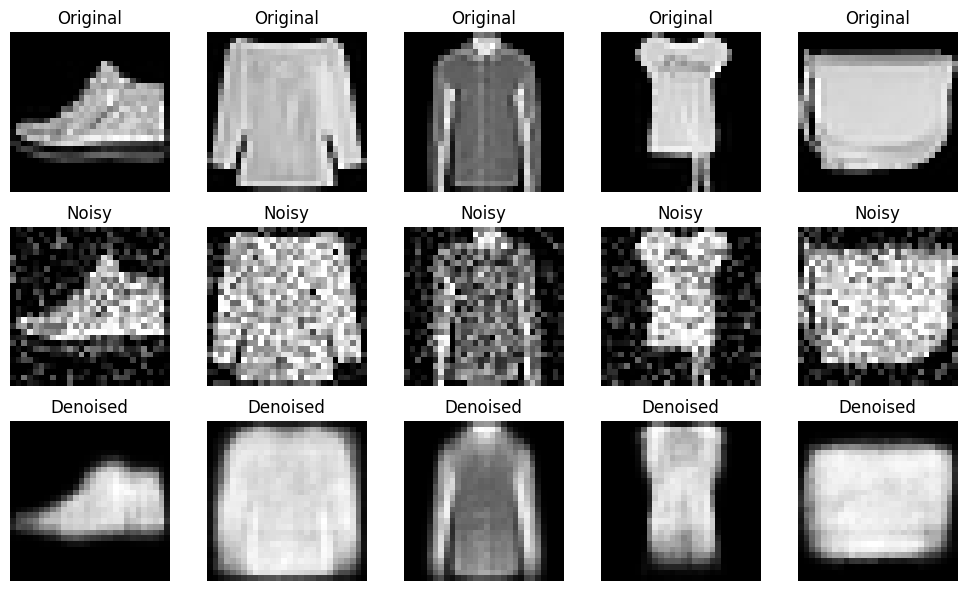

In [8]:

images, _ = next(iter(dataloader))

images = images.view(images.size(0), -1).to(device)

noisy_images = images + 0.2 * torch.randn_like(images)
noisy_images = torch.clamp(noisy_images, 0., 1.)

outputs = model(noisy_images)

# Visualization
fig, axes = plt.subplots(3, 5, figsize=(10,6))

for i in range(5):
    axes[0, i].imshow(images[i].cpu().view(28,28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")

    axes[1, i].imshow(noisy_images[i].cpu().view(28,28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Noisy")

    axes[2, i].imshow(outputs[i].detach().cpu().view(28,28), cmap='gray')
    axes[2, i].axis('off')
    axes[2, i].set_title("Denoised")

plt.tight_layout()
plt.show()



## Dimensionality Reduction using Encoder


Encoded feature shape: (64, 32)


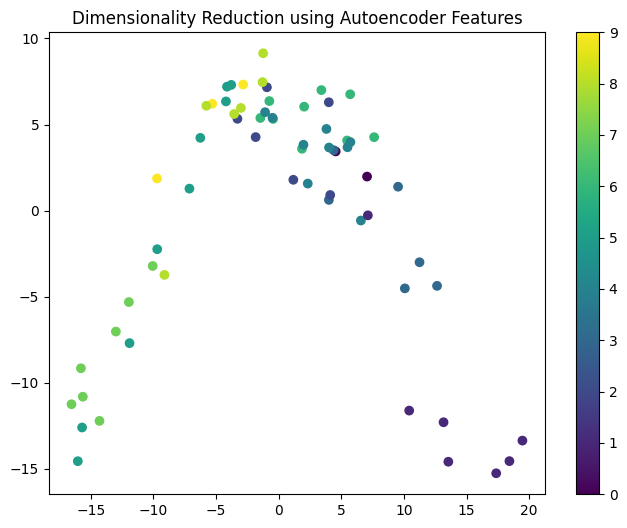

In [9]:

from sklearn.decomposition import PCA

images, labels = next(iter(dataloader))

images = images.view(images.size(0), -1).to(device)

encoded_features = model.encoder(images).detach().cpu().numpy()

print("Encoded feature shape:", encoded_features.shape)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(encoded_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=labels.numpy())
plt.colorbar(scatter)
plt.title("Dimensionality Reduction using Autoencoder Features")
plt.show()



# Conclusion

This notebook demonstrated:
- Autoencoder architecture
- Image denoising
- Feature extraction
- Dimensionality reduction

The same workflow can be applied to Medical MNIST datasets for medical image processing tasks.
